# Chalconatronite Classification — ResNet-50
### Réutilise le dataset déjà splitté (dataset_split/) produit par le notebook EfficientNet-B0

**Ce notebook :**
1. Réutilise `dataset_split/train`, `dataset_split/val`, `dataset_split/test` (aucune ré-extraction de patches)
2. Entraîne ResNet-50 sur ce même dataset
3. Évalue + matrice de confusion + affiche les erreurs
4. Extrait et sauvegarde séparément les faux négatifs et les faux positifs

**Important :** ce notebook part du principe que `dataset_split/` (train/val/test) existe déjà dans le dossier de travail, tel que produit par le notebook EfficientNet-B0. Si vous travaillez dans un nouveau dossier, copiez-y `dataset_split/` avant de lancer ce notebook, ou relancez d'abord les sections 1 à 5 du notebook EfficientNet-B0.

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix

print("Imports OK")
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())

Imports OK
PyTorch : 2.5.1+cu121
CUDA    : True


## 1 — Configuration (réutilise le split existant)

In [4]:
# =============================================================
# CONFIGURATION — seul endroit à modifier
# =============================================================

# Dossiers du split déjà généré par le notebook EfficientNet-B0
TRAIN_DIR = "C:/Users/CD44/Desktop/efficientnet/dataset_split/train"
VAL_DIR   = "C:/Users/CD44/Desktop/efficientnet/dataset_split/val"
TEST_DIR  = "C:/Users/CD44/Desktop/efficientnet/dataset_split/test"

# Paramètres entraînement
BATCH_SIZE     = 32
NUM_EPOCHS     = 15
LR             = 0.001
UNFREEZE_EPOCH = 5      # epoch à partir de laquelle on dégèle les features

CLASS_NAMES = ["with_chalconatronite", "without_chalconatronite"]

MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

CKPT_PATH = "best_resnet50.pth"

# Le split doit déjà exister (généré par le notebook EfficientNet-B0, sections 1 à 5).
# Si vous voulez repartir de zéro sur un autre dossier, relancez plutôt ces
# sections-là avant ce notebook.
for d in (TRAIN_DIR, VAL_DIR, TEST_DIR):
    assert os.path.exists(d), (
        f"{d} introuvable. Lancez d'abord le notebook EfficientNet-B0 "
        f"(sections 1 à 5 : vérification annotations, extraction patches, "
        f"fusion, split) pour générer dataset_split/, ou copiez ce dossier "
        f"depuis l'environnement où il a été créé."
    )
print("dataset_split/ trouvé, split réutilisé tel quel.")

Device : cuda
dataset_split/ trouvé, split réutilisé tel quel.


## 2 — Transforms et DataLoaders

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN.tolist(), std=STD.tolist())
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN.tolist(), std=STD.tolist())
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = train_dataset.classes
print("Classes :", class_names)
print(f"Train : {len(train_dataset)}  |  Val : {len(val_dataset)}  |  Test : {len(test_dataset)}")

Classes : ['with_chalconatronite', 'without_chalconatronite']
Train : 4463  |  Val : 892  |  Test : 594


## 3 — Modèle ResNet-50

In [6]:
model = models.resnet50(pretrained=True)

# Phase 1 : backbone gelé, seule la tête (fc) s'entraîne
for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 2)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres entraînables (tête seule) : {trainable:,}")
print(f"À l'epoch {UNFREEZE_EPOCH}, le backbone sera dégelé.")

c:\Users\CD44\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\CD44\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Paramètres entraînables (tête seule) : 4,098
À l'epoch 5, le backbone sera dégelé.


c:\Users\CD44\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 4 — Entraînement

In [7]:
history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
best_val_acc = 0

for epoch in range(NUM_EPOCHS):

    if epoch == UNFREEZE_EPOCH:
        for param in model.parameters():
            param.requires_grad = True
        optimizer = optim.Adam(model.parameters(), lr=LR / 10)
        print(f" → Epoch {epoch+1} : backbone dégelé, lr={LR/10:.5f}")

    model.train()
    running_loss = correct = total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc  = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    model.eval()
    val_loss = val_correct = val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss    += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs, 1)
            val_total   += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc  = 100 * val_correct / val_total
    val_loss = val_loss / len(val_loader)
    scheduler.step(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  "
          f"Train: {train_acc:.2f}% / loss {train_loss:.4f}  |  "
          f"Val: {val_acc:.2f}% / loss {val_loss:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"   → nouveau meilleur modèle sauvegardé ({val_acc:.2f}%)")

print(f"Meilleure accuracy validation : {best_val_acc:.2f}%")

Epoch [ 1/15]  Train: 84.79% / loss 0.3630  |  Val: 90.36% / loss 0.2415
   → nouveau meilleur modèle sauvegardé (90.36%)
Epoch [ 2/15]  Train: 88.60% / loss 0.2875  |  Val: 94.17% / loss 0.2150
   → nouveau meilleur modèle sauvegardé (94.17%)
Epoch [ 3/15]  Train: 89.45% / loss 0.2684  |  Val: 91.26% / loss 0.2107
Epoch [ 4/15]  Train: 89.02% / loss 0.2724  |  Val: 92.83% / loss 0.1934
Epoch [ 5/15]  Train: 89.09% / loss 0.2679  |  Val: 93.83% / loss 0.1803
 → Epoch 6 : backbone dégelé, lr=0.00010
Epoch [ 6/15]  Train: 92.49% / loss 0.1941  |  Val: 97.42% / loss 0.0909
   → nouveau meilleur modèle sauvegardé (97.42%)
Epoch [ 7/15]  Train: 95.65% / loss 0.1112  |  Val: 97.53% / loss 0.0613
   → nouveau meilleur modèle sauvegardé (97.53%)
Epoch [ 8/15]  Train: 96.84% / loss 0.0838  |  Val: 97.87% / loss 0.0635
   → nouveau meilleur modèle sauvegardé (97.87%)
Epoch [ 9/15]  Train: 98.05% / loss 0.0599  |  Val: 96.41% / loss 0.1105
Epoch [10/15]  Train: 97.51% / loss 0.0686  |  Val: 97.20

## 5 — Courbes d'entraînement

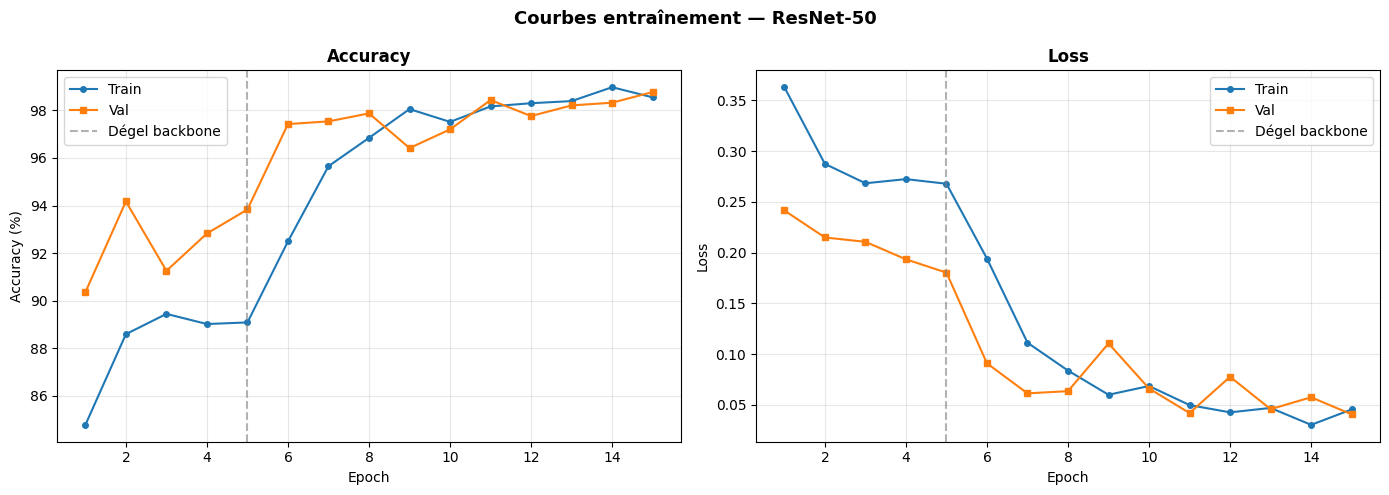

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history['train_acc']) + 1)

ax1.plot(ep, history['train_acc'],  label='Train', marker='o', markersize=4)
ax1.plot(ep, history['val_acc'],    label='Val',   marker='s', markersize=4)
if UNFREEZE_EPOCH < NUM_EPOCHS:
    ax1.axvline(UNFREEZE_EPOCH, color='gray', linestyle='--', alpha=0.6, label='Dégel backbone')
ax1.set_title('Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy (%)'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history['train_loss'], label='Train', marker='o', markersize=4)
ax2.plot(ep, history['val_loss'],   label='Val',   marker='s', markersize=4)
if UNFREEZE_EPOCH < NUM_EPOCHS:
    ax2.axvline(UNFREEZE_EPOCH, color='gray', linestyle='--', alpha=0.6, label='Dégel backbone')
ax2.set_title('Loss', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Courbes entraînement — ResNet-50', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6 — Évaluation sur le test set

Chargement du meilleur modèle...


C:\Users\CD44\AppData\Local\Temp\ipykernel_5920\497096591.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CKPT_PATH))


Classification Report:
                         precision    recall  f1-score   support

   with_chalconatronite       0.99      0.99      0.99       422
without_chalconatronite       0.97      0.98      0.97       172

               accuracy                           0.98       594
              macro avg       0.98      0.98      0.98       594
           weighted avg       0.98      0.98      0.98       594

Confusion Matrix:
[[416   6]
 [  4 168]]


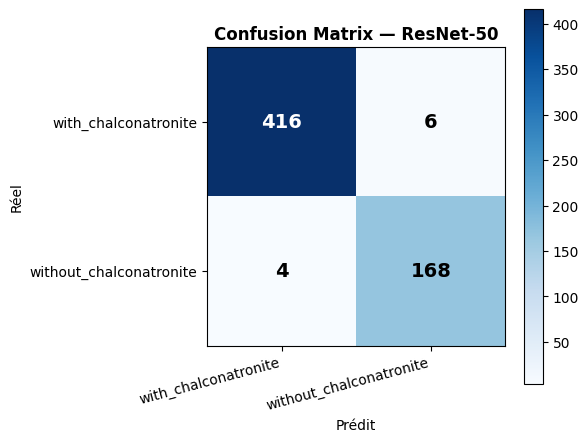

In [9]:
print("Chargement du meilleur modèle...")
model.load_state_dict(torch.load(CKPT_PATH))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(probs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))
print("Confusion Matrix:")
cm_result = confusion_matrix(all_labels, all_preds)
print(cm_result)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_result, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(class_names, rotation=15, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title('Confusion Matrix — ResNet-50', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_result[i, j]),
                ha='center', va='center',
                color='white' if cm_result[i, j] > cm_result.max() / 2 else 'black',
                fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 7 — Faux négatifs et faux positifs (mêmes fichiers, pour comparaison directe avec EfficientNet-B0)

Faux négatifs (ResNet-50) : 6
Faux positifs (ResNet-50) : 4


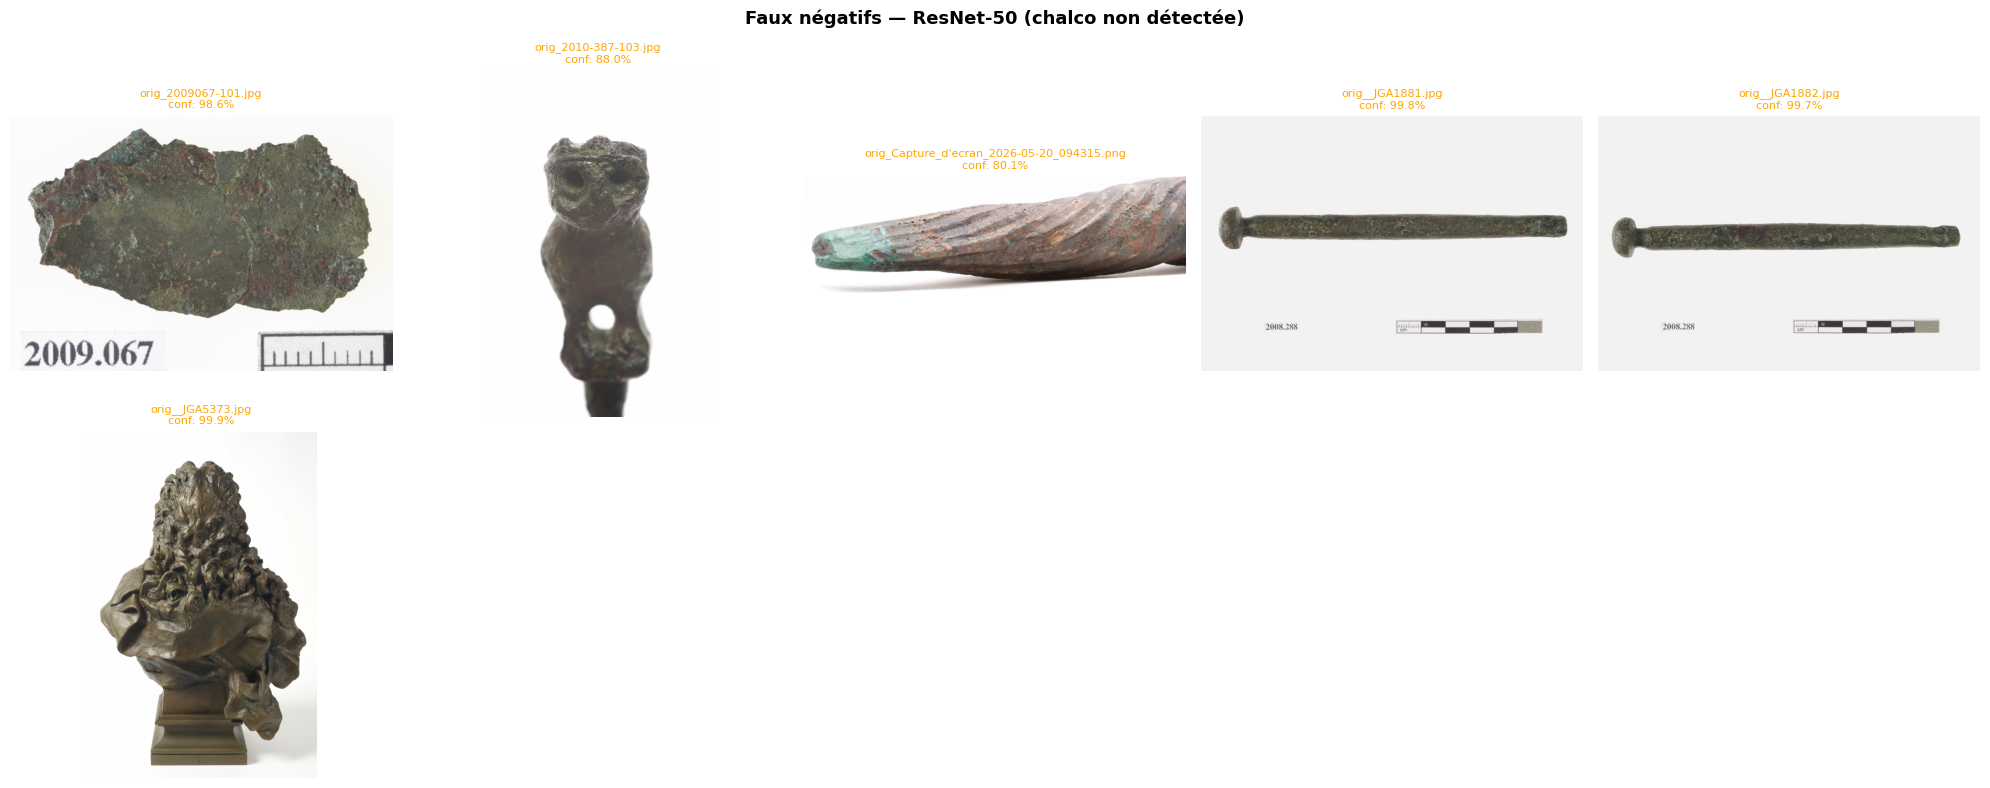

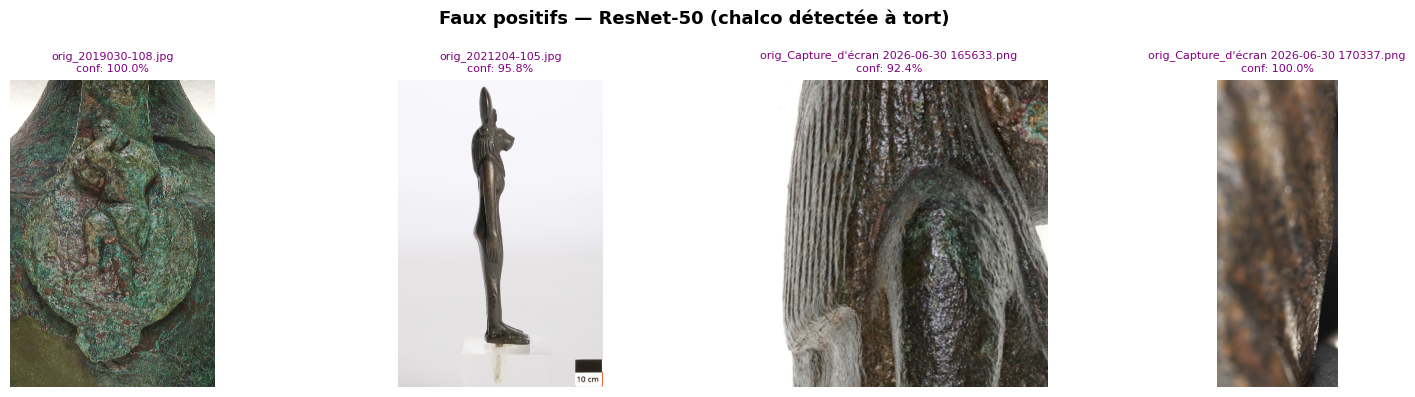

Fichiers en faux négatif :
 - C:/Users/CD44/Desktop/efficientnet/dataset_split/test\with_chalconatronite\orig_2009067-101.jpg
 - C:/Users/CD44/Desktop/efficientnet/dataset_split/test\with_chalconatronite\orig_2010-387-103.jpg
 - C:/Users/CD44/Desktop/efficientnet/dataset_split/test\with_chalconatronite\orig_Capture_d'ecran_2026-05-20_094315.png
 - C:/Users/CD44/Desktop/efficientnet/dataset_split/test\with_chalconatronite\orig__JGA1881.jpg
 - C:/Users/CD44/Desktop/efficientnet/dataset_split/test\with_chalconatronite\orig__JGA1882.jpg
 - C:/Users/CD44/Desktop/efficientnet/dataset_split/test\with_chalconatronite\orig__JGA5373.jpg
Fichiers en faux positif :
 - C:/Users/CD44/Desktop/efficientnet/dataset_split/test\without_chalconatronite\orig_2019030-108.jpg
 - C:/Users/CD44/Desktop/efficientnet/dataset_split/test\without_chalconatronite\orig_2021204-105.jpg
 - C:/Users/CD44/Desktop/efficientnet/dataset_split/test\without_chalconatronite\orig_Capture_d'écran 2026-06-30 165633.png
 - C:/User

In [10]:
# Chemins des images de test, dans le même ordre que test_loader (shuffle=False)
test_filepaths = [p for p, _ in test_dataset.samples]

pos_idx = class_names.index("with_chalconatronite")
neg_idx = class_names.index("without_chalconatronite")

# Faux négatifs : vrai = positif (chalco présente), prédit = négatif → chalco manquée
fn_mask = (all_labels == pos_idx) & (all_preds == neg_idx)
# Faux positifs : vrai = négatif (cuivre propre), prédit = positif → fausse alerte
fp_mask = (all_labels == neg_idx) & (all_preds == pos_idx)

false_negatives = [(test_filepaths[i], all_probs[i]) for i in np.where(fn_mask)[0]]
false_positives = [(test_filepaths[i], all_probs[i]) for i in np.where(fp_mask)[0]]

print(f"Faux négatifs (ResNet-50) : {len(false_negatives)}")
print(f"Faux positifs (ResNet-50) : {len(false_positives)}")

FN_DIR = "errors_resnet50/false_negatives"
FP_DIR = "errors_resnet50/false_positives"
os.makedirs(FN_DIR, exist_ok=True)
os.makedirs(FP_DIR, exist_ok=True)

for path, _ in false_negatives:
    shutil.copy(path, os.path.join(FN_DIR, os.path.basename(path)))
for path, _ in false_positives:
    shutil.copy(path, os.path.join(FP_DIR, os.path.basename(path)))

def show_error_set(items, title_txt, color):
    if not items:
        print(f"Aucune image : {title_txt}")
        return
    n = len(items)
    cols = min(5, n); rows = (n + cols - 1) // cols
    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, (path, probs) in enumerate(items):
        img = Image.open(path).convert("RGB")
        conf = probs[np.argmax(probs)] * 100
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{os.path.basename(path)}\nconf: {conf:.1f}%", color=color, fontsize=8)
    plt.suptitle(title_txt, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_error_set(false_negatives, "Faux négatifs — ResNet-50 (chalco non détectée)", "orange")
show_error_set(false_positives, "Faux positifs — ResNet-50 (chalco détectée à tort)", "purple")

print("Fichiers en faux négatif :")
for path, _ in false_negatives:
    print(" -", path)
print("Fichiers en faux positif :")
for path, _ in false_positives:
    print(" -", path)